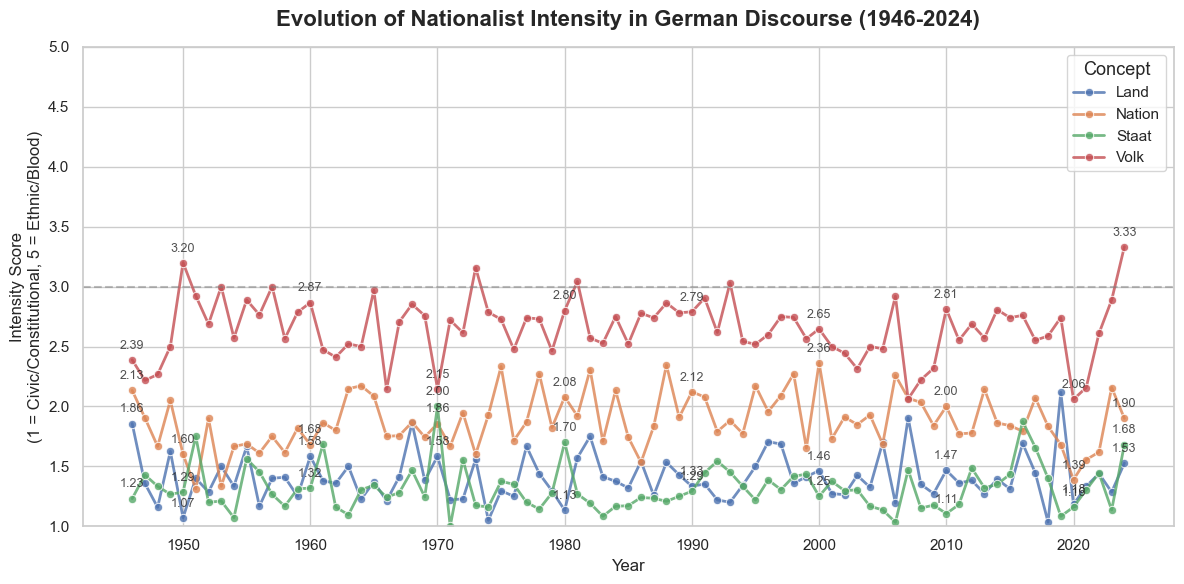

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = ['Arial', 'sans-serif']
plt.rcParams['axes.unicode_minus'] = False

input_file = 'data/corpus/final_corpus_annotated.csv'
df = pd.read_csv(input_file)
df['Intensity'] = pd.to_numeric(df['Intensity'], errors='coerce')
df['Valence'] = pd.to_numeric(df['Valence'], errors='coerce')
df_clean = df.dropna(subset=['Intensity', 'Valence', 'Year', 'Keyword']).copy()

yearly_stats = df_clean.groupby(['Year', 'Keyword'], observed=False)[['Intensity', 'Valence']].mean().reset_index()

# ---------------------------------------------------------
# Plot 1: Nationalist Intensity over Time (With Data Labels)
# ---------------------------------------------------------
plt.figure(figsize=(12, 6))
ax1 = sns.lineplot(
    data=yearly_stats, 
    x='Year', 
    y='Intensity', 
    hue='Keyword', 
    marker='o',
    linewidth=2,
    alpha=0.8
)

plt.title('Evolution of Nationalist Intensity in German Discourse (1946-2024)', fontsize=16, fontweight='bold', pad=15)
plt.ylabel('Intensity Score\n(1 = Civic/Constitutional, 5 = Ethnic/Blood)', fontsize=12)
plt.xlabel('Year', fontsize=12)
plt.ylim(1, 5)
plt.axhline(y=3, color='gray', linestyle='--', alpha=0.5)

label_interval = 10 
for line in ax1.lines:
    x_data = line.get_xdata()
    y_data = line.get_ydata()
    
    for i in range(len(x_data)):
        if int(x_data[i]) % label_interval == 0 or i == 0 or i == len(x_data) - 1:
            ax1.annotate(
                f'{y_data[i]:.2f}', # Format to 2 decimal places (e.g., "3.45")
                (x_data[i], y_data[i]),
                textcoords="offset points",
                xytext=(0, 8), # Offset slightly above the point
                ha='center', 
                fontsize=9,
                alpha=0.8
            )

plt.legend(title='Concept', title_fontsize='13', fontsize='11', loc='upper right')
plt.tight_layout()

plt.savefig('figures/plot_intensity_trend.png', dpi=300)
plt.show()

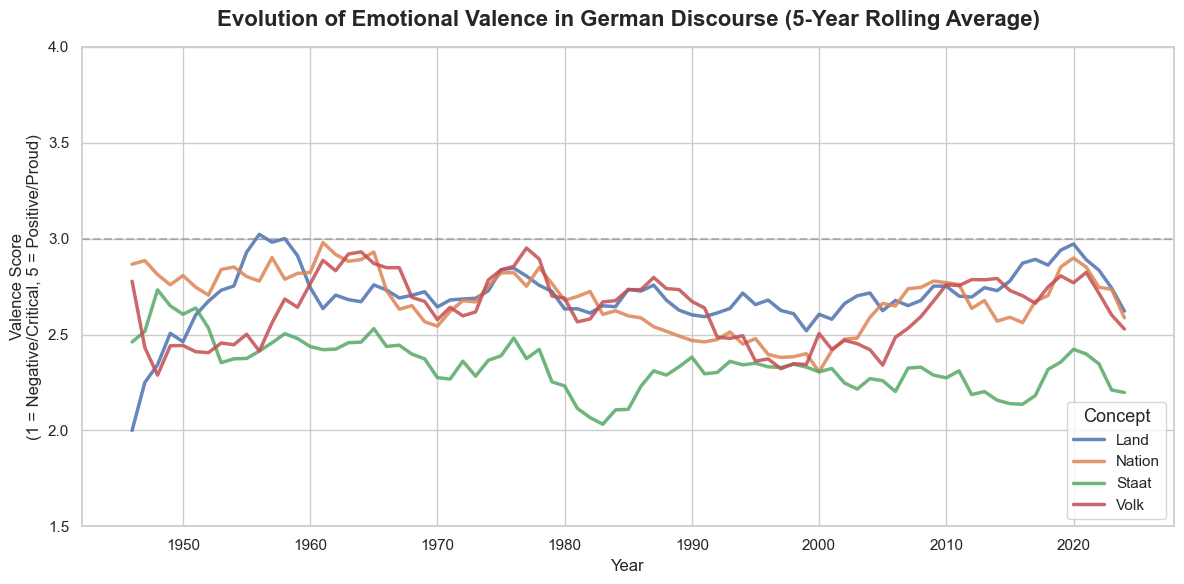

In [8]:
# ---------------------------------------------------------
# Plot 2: Emotional Valence over Time (Smoothed & De-cluttered)
# ---------------------------------------------------------
plt.figure(figsize=(12, 6))

yearly_stats['Valence_Smoothed'] = yearly_stats.groupby('Keyword')['Valence'].transform(lambda x: x.rolling(window=5, min_periods=1).mean())

ax2 = sns.lineplot(
    data=yearly_stats, 
    x='Year', 
    y='Valence_Smoothed', 
    hue='Keyword', 
    linewidth=2.5, 
    alpha=0.85
)

plt.title('Evolution of Emotional Valence in German Discourse (5-Year Rolling Average)', fontsize=16, fontweight='bold', pad=15)
plt.ylabel('Valence Score\n(1 = Negative/Critical, 5 = Positive/Proud)', fontsize=12)
plt.xlabel('Year', fontsize=12)
plt.ylim(1.5, 4.0) 
plt.axhline(y=3, color='gray', linestyle='--', alpha=0.5)
plt.legend(title='Concept', title_fontsize='13', fontsize='11', loc='lower right')
plt.tight_layout()

plt.savefig('figures/plot_valence_trend.png', dpi=300)
plt.show()

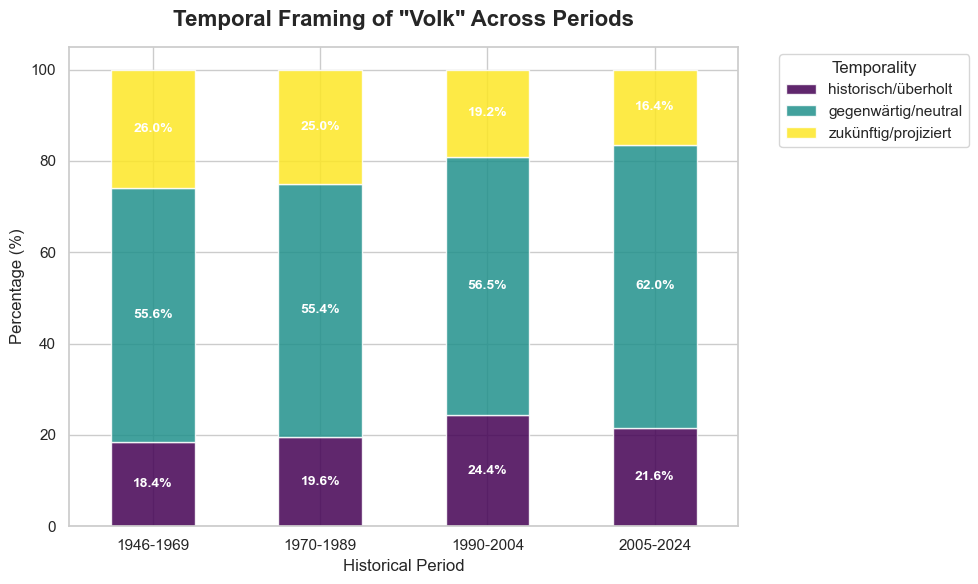

In [7]:
# ---------------------------------------------------------
# Plot 3: Temporality Distribution over Periods (Stacked Bar with Labels)
# ---------------------------------------------------------
valid_temp = ['historisch/überholt', 'gegenwärtig/neutral', 'zukünftig/projiziert']
df_temp = df_clean[df_clean['Temporality'].isin(valid_temp)].copy()

keyword_to_plot = 'Volk'
df_kw = df_temp[df_temp['Keyword'] == keyword_to_plot]

if not df_kw.empty:
    cross_tab = pd.crosstab(df_kw['Period'], df_kw['Temporality'], normalize='index') * 100
    
    ordered_cols = [c for c in valid_temp if c in cross_tab.columns]
    cross_tab = cross_tab[ordered_cols]
    
    ax3 = cross_tab.plot(kind='bar', stacked=True, figsize=(10, 6), colormap='viridis', alpha=0.85)
    
    for container in ax3.containers:
        labels = [f'{v.get_height():.1f}%' if v.get_height() > 2 else '' for v in container]
        ax3.bar_label(container, labels=labels, label_type='center', fontsize=10, color='white', weight='bold')
    
    plt.title(f'Temporal Framing of "{keyword_to_plot}" Across Periods', fontsize=16, fontweight='bold', pad=15)
    plt.ylabel('Percentage (%)', fontsize=12)
    plt.xlabel('Historical Period', fontsize=12)
    plt.xticks(rotation=0)
    
    plt.legend(title='Temporality', bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    
    plt.savefig(f'figures/plot_temporality_{keyword_to_plot}.png', dpi=300)
    plt.show()
else:
    print(f"⚠️ No valid temporality data found for '{keyword_to_plot}' yet.")